In [21]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)

In [22]:
glass_data <- read.table(
  "/scratch/mjehangir/Glioma_project/BISCUT/results_2025_04_1_glass_0.95/KS_pvalues_2025_04_1_glass_0.95.txt",
  header = TRUE,
  sep = "\t",
  quote = "\""
)
head(data)


,combo,one_samp_p,ks_stat,by,bonferroni,significant
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,glass_10p_amp_tel_p_1,0.0003566859,0.5195815,0.02006004,0.01783429,TRUE
2,glass_10p_del_tel_n_1,0.0962842540,0.5508140,1.00000000,1.00000000,FALSE
3,glass_11p_amp_cent_n_1,0.7923643313,0.2456312,1.00000000,1.00000000,FALSE
4,glass_11p_del_tel_p_1,0.7734247762,0.1170593,1.00000000,1.00000000,FALSE
5,glass_11q_amp_cent_p_1,0.0666098957,0.6521739,0.99897200,1.00000000,FALSE
6,glass_11q_amp_tel_p_1,0.1379719271,0.3091140,1.00000000,1.00000000,FALSE


In [23]:
significant_df <- glass_data %>%
  filter(by < 0.05)

head(significant_df)

,combo,one_samp_p,ks_stat,by,bonferroni
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,glass_10p_amp_tel_p_1,3.566859e-04,0.5195815,0.0200600373,1.783429e-02
2,glass_12p_del_tel_n_1,8.606722e-04,0.8804634,0.0387234076,4.303361e-02
3,glass_2q_del_tel_n_1,9.226822e-07,0.5760204,0.0002050378,4.613411e-05
4,glass_3q_del_tel_n_1,1.822880e-06,0.6594317,0.0002050378,9.114399e-05
5,glass_7q_amp_tel_p_1,1.256450e-04,0.4691894,0.0094217145,6.282252e-03


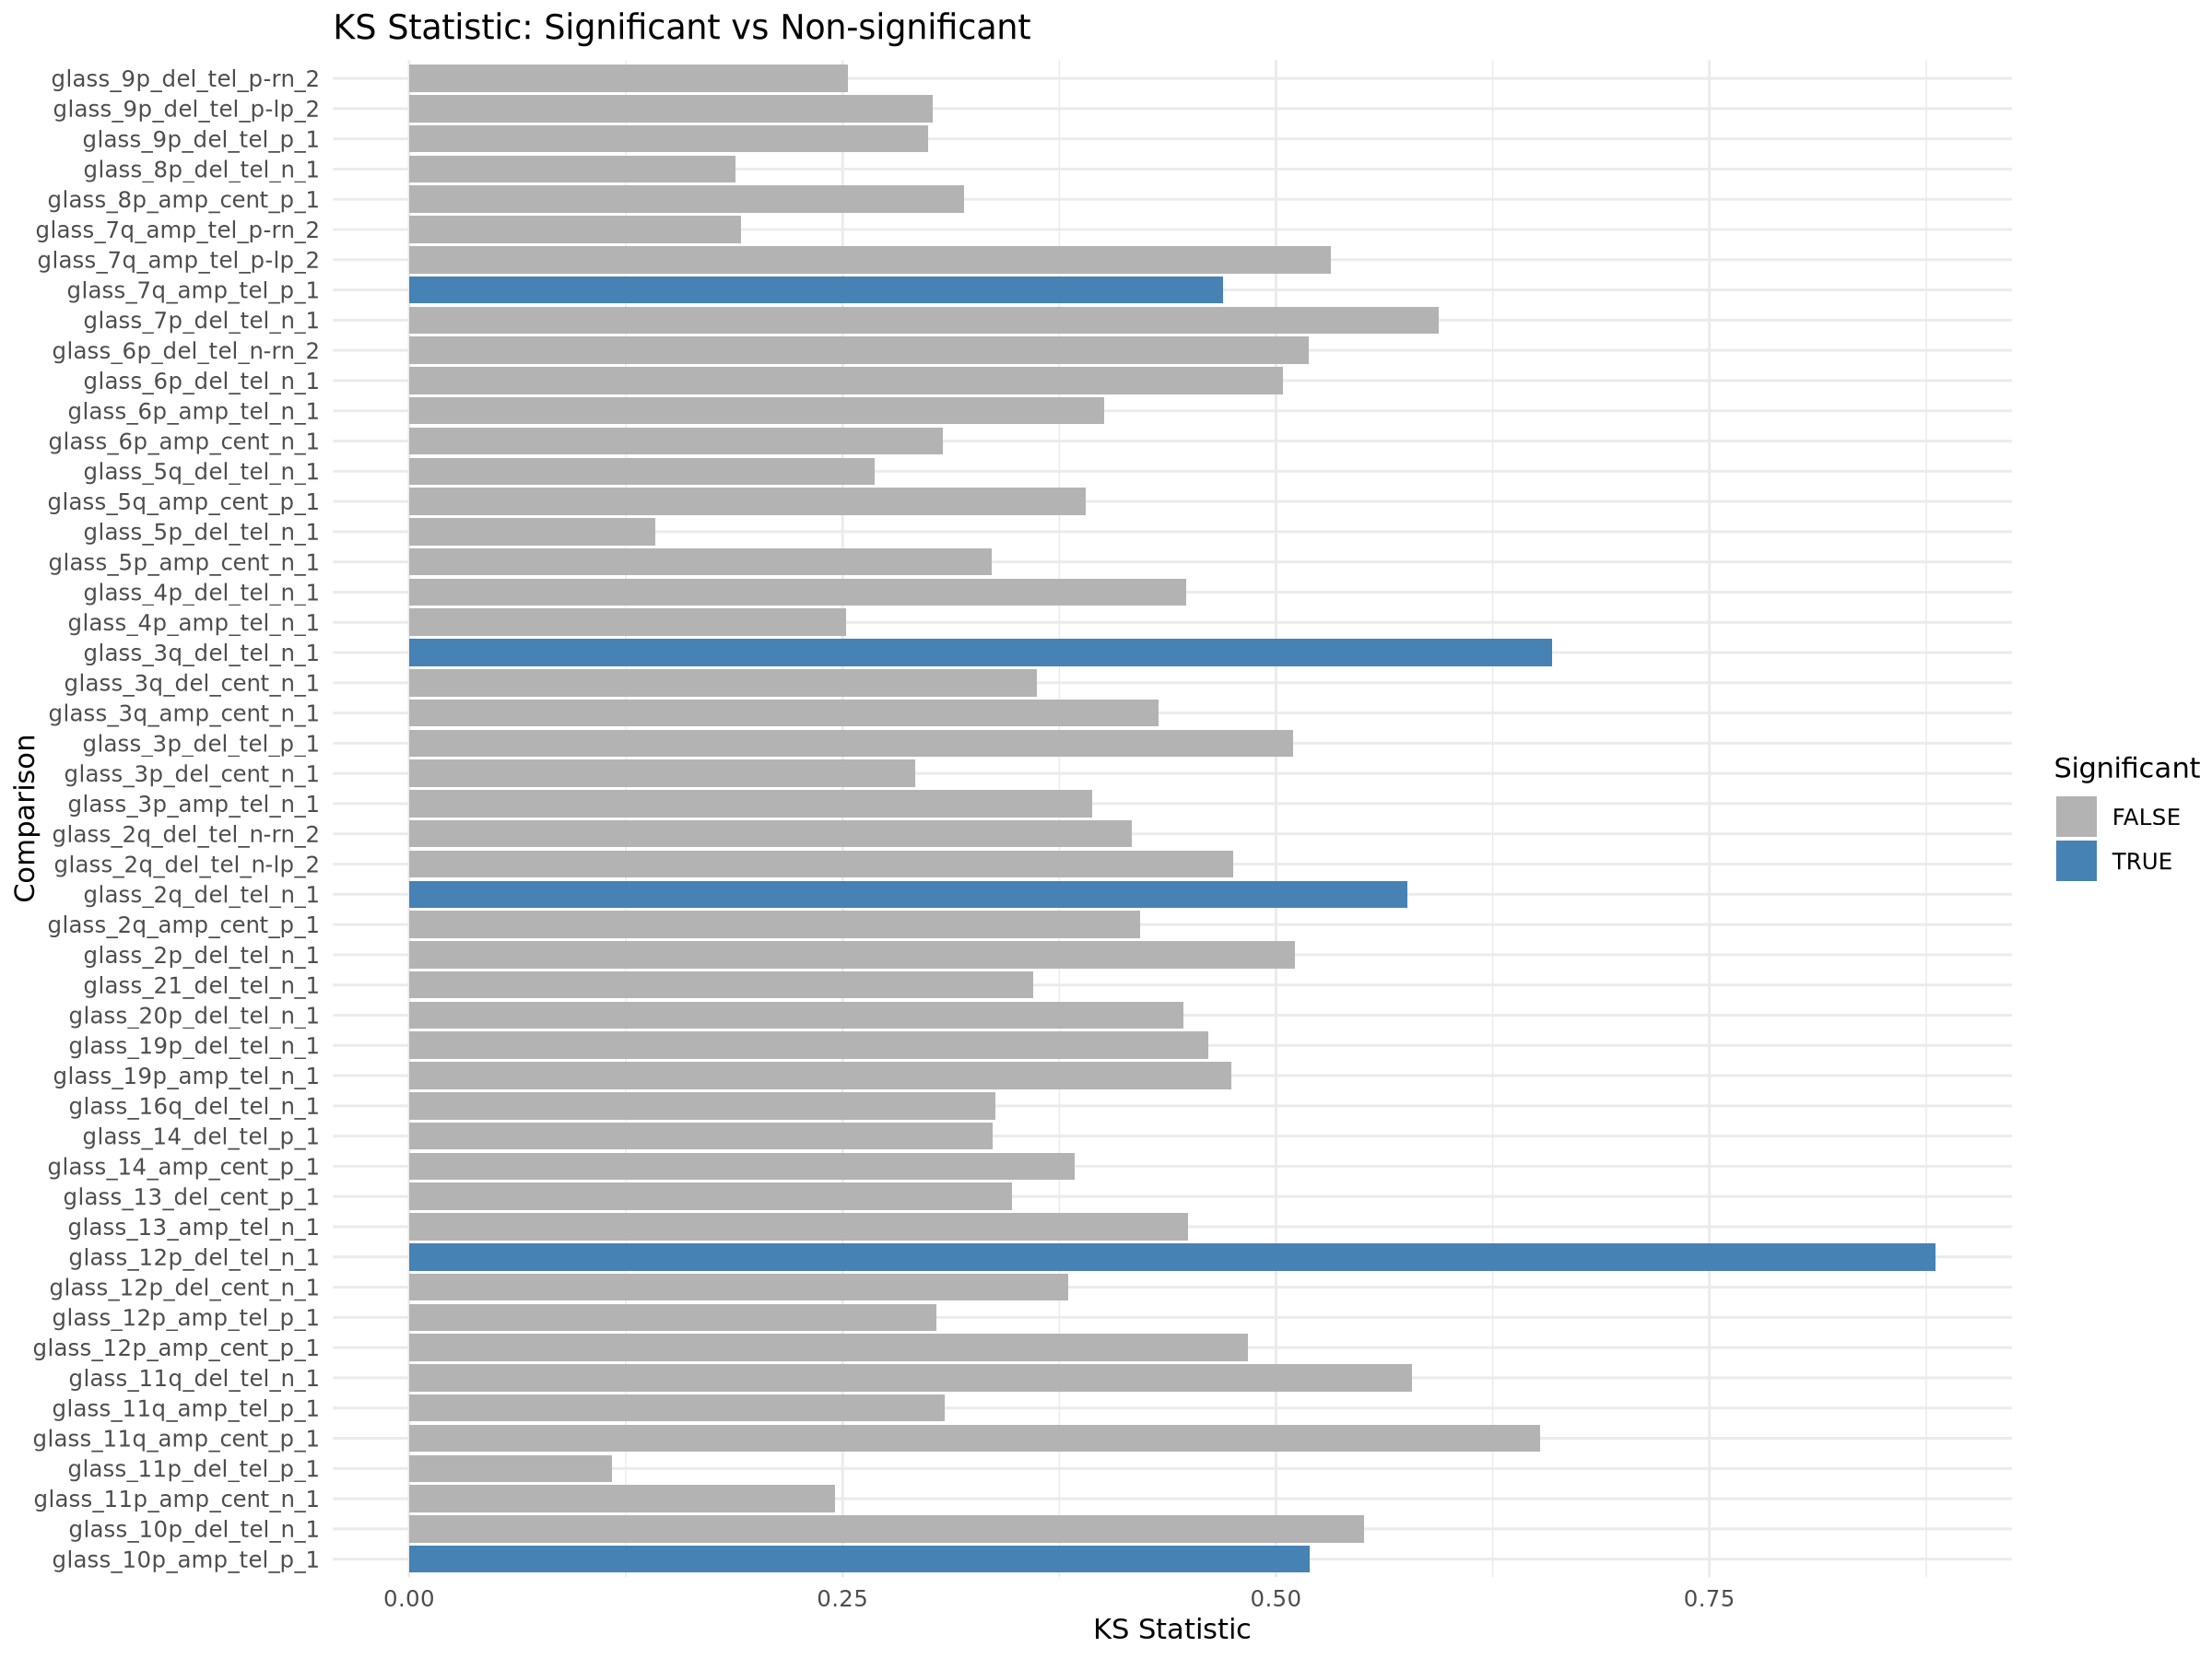

In [24]:

# Add significance column to original data
glass_data <- glass_data %>%
  mutate(significant = by < 0.05)
options(repr.plot.width = 12, repr.plot.height = 9, repr.plot.res = 200)

# Plot with color based on significance
ggplot(glass_data, aes(x = combo, y = ks_stat, fill = significant)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  scale_fill_manual(values = c("FALSE" = "grey70", "TRUE" = "steelblue")) +
  theme_minimal() +
  labs(
    title = "KS Statistic: Significant vs Non-significant",
    x = "Comparison",
    y = "KS Statistic",
    fill = "Significant"
  )



In [14]:
# Read the data
ONT_data <- read.table("/scratch/mjehangir/Glioma_project/BISCUT/results_2025_04_1_0.95_v1/KS_pvalues_2025_04_1_0.95.txt", 
  header = TRUE,
  sep = "\t",
  quote = "\""
)
head(ONT_data)


,combo,one_samp_p,ks_stat,by,bonferroni
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,glioma_10p_amp_tel_n_1,0.90299356,0.2600000,1.0000000,1.0000000
2,glioma_11p_del_tel_n_1,0.75854423,0.2159800,1.0000000,1.0000000
3,glioma_11q_amp_tel_n_1,0.72001179,0.3200000,1.0000000,1.0000000
4,glioma_16p_del_tel_p_1,0.33738979,0.3707865,1.0000000,1.0000000
5,glioma_17p_del_tel_n_1,0.29999572,0.4578652,1.0000000,1.0000000
6,glioma_19p_del_tel_p_1,0.07125452,0.4282147,0.5917448,0.7837998


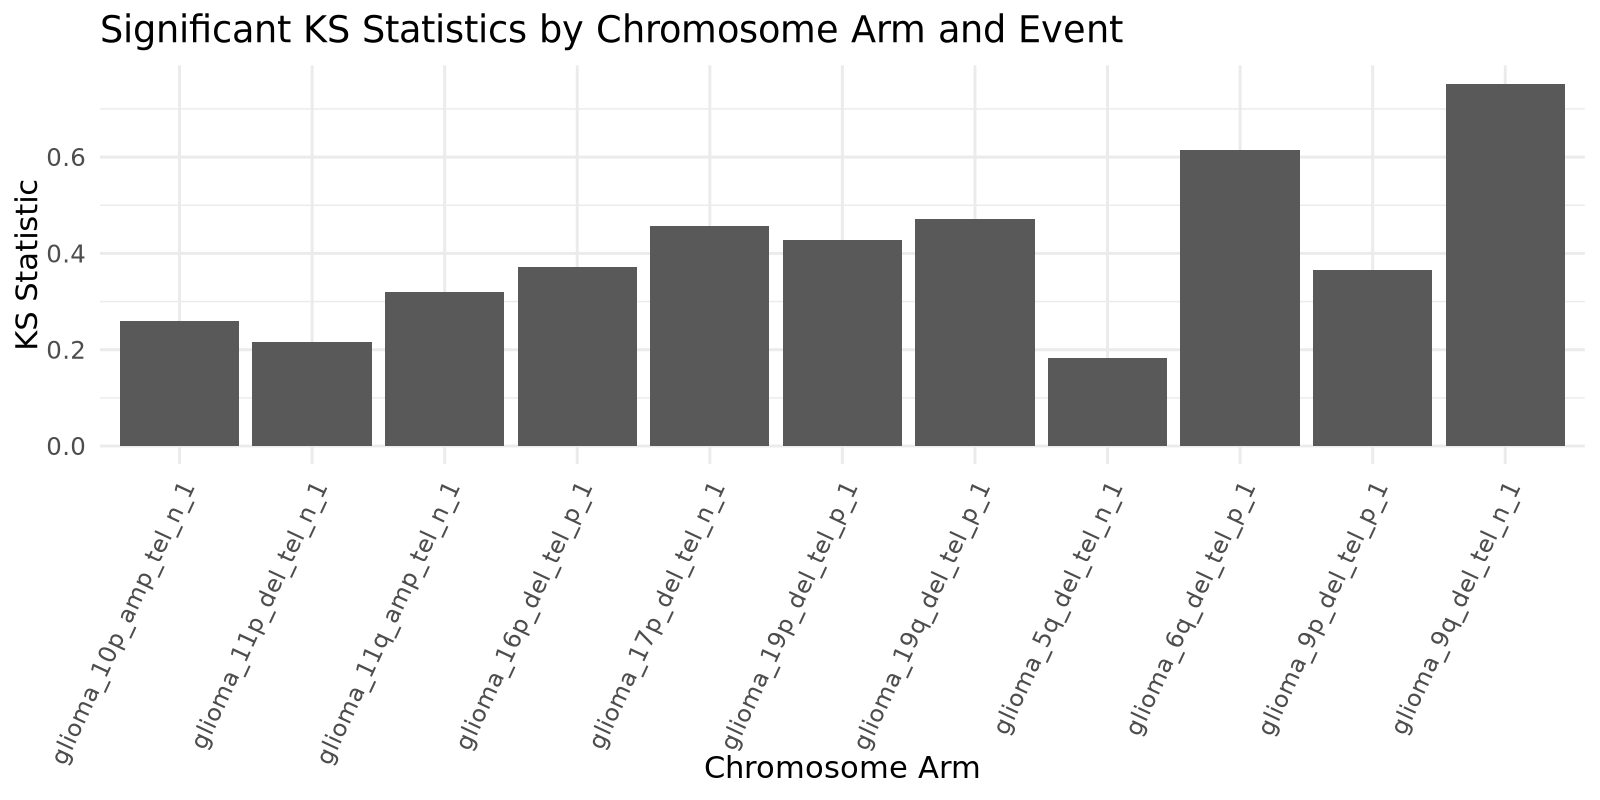

In [19]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)

ggplot(ONT_data, aes(x = combo, y = ks_stat)) +
  geom_bar(stat = "identity", position = "dodge") +
  theme_minimal() +
  labs(
    title = "Significant KS Statistics by Chromosome Arm and Event",
    x = "Chromosome Arm",
    y = "KS Statistic"
  ) +
  theme(axis.text.x = element_text(angle = 65, hjust = 1))
